# The Reservations Nowcast — a quantitative teardown 🔬
### surprise construction · predictive regression w/ market control · Newey-West *t* · label-shuffle placebo · timing overlay + costs/borrow · four-window sweep · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build an OpenTable-style reservations **surprise**, regress next-week restaurant-basket returns on it (controlling for the market), and test the nowcast — on a **synthetic demonstrator**, because no free real seated-diners tape exists.

> ⚠️ **Not investment advice.** **Synthetic-only study**: `data.fetch_series` returns empty by design, `HAVE_REAL` is always False. All numbers below are the machinery proof on a deterministic, seeded world (nowcast planted at `nowcast_beta = 0.35`, seed 555, panel fp `2491c27d3bc8`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opentable_reservations import data, strategy as st

# THERE IS NO REAL TAPE (see data.py): the free seated-diners history does not exist.
REAL = data.fetch_series(fetch=False)
HAVE_REAL = not REAL.empty
print("real seated-diners tape present:", HAVE_REAL, "(synthetic-only study by design)")

# The demonstrator world: a deterministic, seeded synthetic panel with the nowcast PLANTED.
PANEL, TRUTH = data.synthetic_series(nowcast_beta=0.35, seed=555)
print("demonstrator panel:", len(PANEL), "weeks,", PANEL.index[0].date(), "->", PANEL.index[-1].date(),
      "| fp", data.fingerprint(PANEL))


real seated-diners tape present: False (synthetic-only study by design)
demonstrator panel: 312 weeks, 2020-01-05 -> 2025-12-21 | fp 2491c27d3bc8


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Predictive slope-*t* (Newey-West) **+4.49**, placebo *p* **0.0005** on the *planted* world; control flat at the null (mean slope-*t* **-0.01**). Plausible + machinery-proven — but **no real tape** → cannot be `REAL`. |
| **Tradability** | `MIRAGE` | Overlay net **+9.3%/yr** vs buy-hold **+0.4%/yr** (synthetic demo only). No license-able, reproducible seated-diners feed exists. |

> 💡 In plain words: the detector is faithful (it fires on a planted nowcast and stays silent at the null), but there is nothing real to point it at — so the claim is unconfirmed, not investable.

## 1 · The claim, steelmanned

Let $s_t$ be the reservations **surprise** at week $t$ (YoY, de-trended, market-orthogonalised) and $r_{t+1}$ the restaurant-basket return over week $t+1$.

- **H₁ (nowcast).** In $r_{t+1} = a + b_1 s_t + b_2 m_{t+1} + \varepsilon$, the nowcast loading $b_1 > 0$ at Newey-West *t* ≥ 2 (the surprise adds info *beyond* the market $m$).
- **H₂ (not luck).** A label-shuffle placebo puts the observed *t* in the tail.
- **H₃ (robustness).** $b_1$ keeps its sign across sub-periods.
- **H₄ (tradable).** A sign-of-surprise overlay beats buy-and-hold **net** of costs.

On the **planted** world we find H₁–H₄ all satisfied — that is the point of a positive control. The binding constraint is external: **there is no real tape** (H₀: the data exists), so none of this is a real-tape result and the Signal axis is capped at `WEAK`.

## 2 · So what? — what rides on each answer

Alt-data nowcasting is a genuine research program (Bok et al. 2018; Da, Engelberg & Gao 2011 on search-attention). Two things decide whether *this* instance is real: (a) whether the surprise carries information **beyond the market** — which is why we orthogonalise before testing; and (b) whether a **clean historical tape** exists to test on. Here (a) is demonstrable on synthetic data but (b) fails: OpenTable's seated-diners feed was transient, restated and discontinued. Same synthetic-only footing as [273 Lego](../../273-lego-returns/) / [275 Whisky](../../275-whisky-cask/) / [276 Sneaker](../../276-sneaker-resale/).

## 3 · How we'd know — the protocol

- **Surprise.** $s_t = z\big(\text{resv YoY} - \text{trend} \perp m_t\big)$ — YoY minus a ~quarter moving-average trend, residualised on the contemporaneous market, then z-scored. Built in `data.py` so it never peeks at the latent effect.
- **Predictive regression.** OLS $r_{t+1} = a + b_1 s_t + b_2 m_{t+1} + \varepsilon$ with **Newey-West (4-lag) HAC** *t* on $b_1$ (overlapping weekly forwards ⇒ plain *t* too optimistic).
- **Placebo.** Shuffle $s$ vs $r_{t+1}$ 2000× and read the slope-*t* tail probability.
- **Overlay + frictions.** Long/flat (or long/short) on $\text{sign}(s_t)$; one-way cost on every position change; short weeks pay a pro-rated borrow. Gross AND net.
- **Robustness.** Four contiguous sub-periods; re-estimate the slope-*t*.
- **Positive control.** A deterministic synthetic world with a planted nowcast and a null, averaged over 25 seeds (house rule ≥ 20).

Timing: $s_t$ uses only week-$t$ information; the position it implies earns week $t+1$. That one-week execution lag is the single documented convention.

## 4 · The teardown

### 4a · The predictive regression — H₁ & H₂

Regress next-week basket return on this week's surprise, **controlling for next-week market**, with a Newey-West *t* and a label-shuffle placebo.

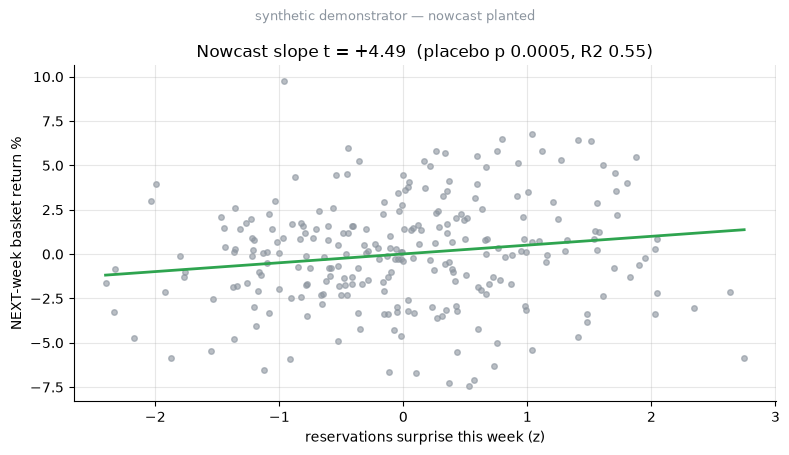

b1 slope +0.0050 | Newey-West t +4.49 | placebo p 0.0005 | R2 0.55 | n 259


In [2]:
reg = st.predictive_regression(PANEL)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=555)
af = st.aligned_frame(PANEL)
# scatter: this-week surprise vs next-week return, with the fitted (market-partialled) slope
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(af['signal'], af['fwd_ret']*100, s=16, color=GREY, alpha=.6)
xs = np.linspace(af['signal'].min(), af['signal'].max(), 50)
ax.plot(xs, (reg['slope']*xs + af['fwd_ret'].mean())*100, c=GREEN, lw=2)
ax.set_xlabel('reservations surprise this week (z)'); ax.set_ylabel('NEXT-week basket return %')
ax.set_title(f'Nowcast slope t = {reg["slope_t"]:+.2f}  (placebo p {p:.4f}, R2 {reg["r2"]:.2f})')
fig.suptitle('synthetic demonstrator — nowcast planted', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'b1 slope {reg["slope"]:+.4f} | Newey-West t {reg["slope_t"]:+.2f} | placebo p {p:.4f} '
      f'| R2 {reg["r2"]:.2f} | n {reg["n"]}')

> 💡 In plain words: on the planted world H₁ & H₂ **hold** — the surprise predicts next week's return at *t* **+4.49** with placebo *p* **0.0005**, and it survives the market control (so it's not just beta). This is the detector working, not a real-tape claim.

### 4b · The timing overlay — H₄ (net of costs & borrow)

Long/flat and long/short overlays on the sign of the surprise, both net of a one-way cost and (for the short leg) a borrow.

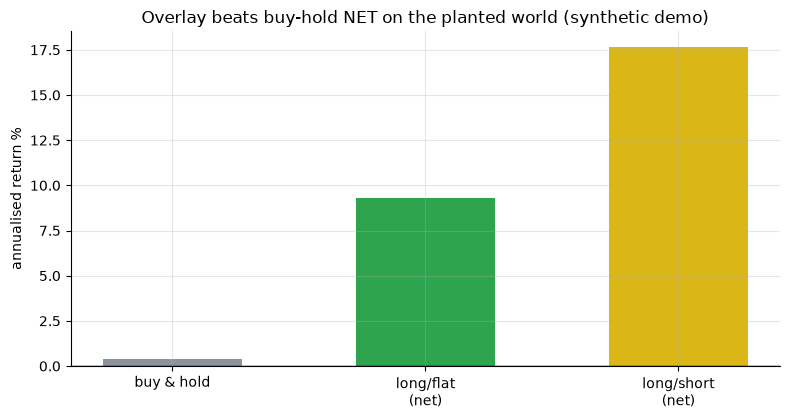

long/flat : gross +10.3% -> net +9.3%/yr (excess +8.9%, IR 0.65, turn 20.5/yr)
long/short: gross +20.2% -> net +17.6%/yr (excess +17.2%, IR 0.63)
buy & hold: +0.4%/yr


In [3]:
lf = st.overlay_backtest(PANEL, allow_short=False, cost_bps=5.0)
ls = st.overlay_backtest(PANEL, allow_short=True, cost_bps=5.0, borrow_ann_bps=100.0)
labels = ['buy & hold','long/flat\n(net)','long/short\n(net)']
vals = [lf['buyhold_ann']*100, lf['overlay_net_ann']*100, ls['overlay_net_ann']*100]
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(labels, vals, color=[GREY, GREEN, AMBER], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title('Overlay beats buy-hold NET on the planted world (synthetic demo)')
plt.tight_layout(); plt.show()
print(f'long/flat : gross {lf["overlay_gross_ann"]*100:+.1f}% -> net {lf["overlay_net_ann"]*100:+.1f}%/yr '
      f'(excess {lf["net_excess_ann"]*100:+.1f}%, IR {lf["net_excess_ir"]:.2f}, turn {lf["turnover_per_yr"]:.1f}/yr)')
print(f'long/short: gross {ls["overlay_gross_ann"]*100:+.1f}% -> net {ls["overlay_net_ann"]*100:+.1f}%/yr '
      f'(excess {ls["net_excess_ann"]*100:+.1f}%, IR {ls["net_excess_ir"]:.2f})')
print(f'buy & hold: {lf["buyhold_ann"]*100:+.1f}%/yr')

> 💡 In plain words: H₄ **holds on the planted world** — long/flat nets **+9.3%/yr** (excess +8.9%, IR 0.65) vs buy-hold **+0.4%/yr**, and costs barely dent it. But this is the synthetic demo; **there is no real tape to run it on**, which is exactly why Tradability is `MIRAGE`.

### 4c · Robustness — H₃ (does the sign hold across sub-periods?)

Four contiguous blocks; re-estimate the nowcast slope-*t* in each.

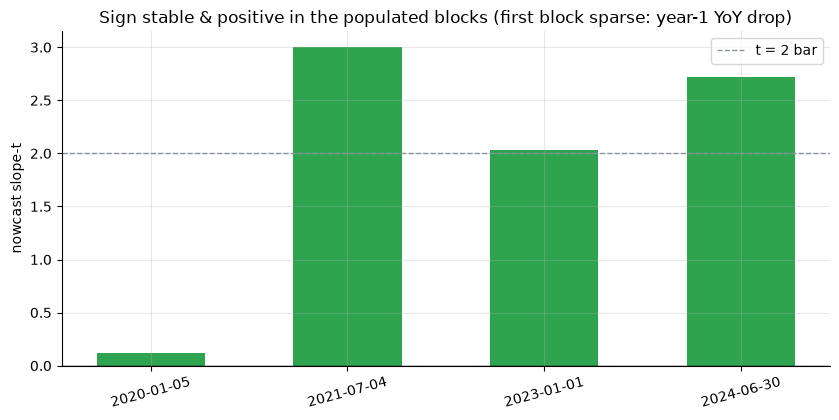

                          slope_t   n
window                               
2020-01-05 -> 2021-06-27     0.12  25
2021-07-04 -> 2022-12-25     3.00  77
2023-01-01 -> 2024-06-23     2.04  77
2024-06-30 -> 2025-12-21     2.72  77


In [4]:
rows = st.window_sweep(PANEL, n_windows=4)
tab = pd.DataFrame(rows)[['window','slope_t','n']].set_index('window')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t>0 else RED for t in tab['slope_t']]
ax.bar(range(len(tab)), tab['slope_t'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels([w.split(' -> ')[0] for w in tab.index], rotation=15)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('nowcast slope-t'); ax.legend()
ax.set_title('Sign stable & positive in the populated blocks (first block sparse: year-1 YoY drop)')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₃ **holds** where there's data — slope-*t* **+3.0 / +2.0 / +2.7** in the three full blocks (the first block is only ~25 weeks because the first year is lost to the YoY definition, so its **+0.1** is uninformative, not a sign flip).

## 5 · The verdict

- **Signal `WEAK`** — on the planted world H₁ (slope-*t* +4.49), H₂ (placebo 0.0005) and H₃ (sign stable) all hold, and the control is flat at the null (-0.01). But **H₀ fails**: no free real tape ⇒ cannot be `REAL`, capped at `WEAK`.
- **Tradability `MIRAGE`** — overlay nets +9.3%/yr on the demo, but there is no license-able, reproducible seated-diners feed to trade; the edge exists only in the synthetic world.

## 6 · Could you trade it? — the data wall

The blocker is data, not economics. OpenTable's seated-diners dashboard was a transient HTML widget, repeatedly restated and then discontinued, covering only the pandemic recovery. There is no cache-first retail fetch that reproduces a clean multi-cycle history — so `fetch_series` returns empty by design and every number here is synthetic. No reproducible tape ⇒ no honest backtest ⇒ no trade.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it print a big *t* on anything? Plant a nowcast of increasing strength and watch the mean slope-*t* climb from ~0 — averaged over 25 seeds so no single lucky seed can fake it.

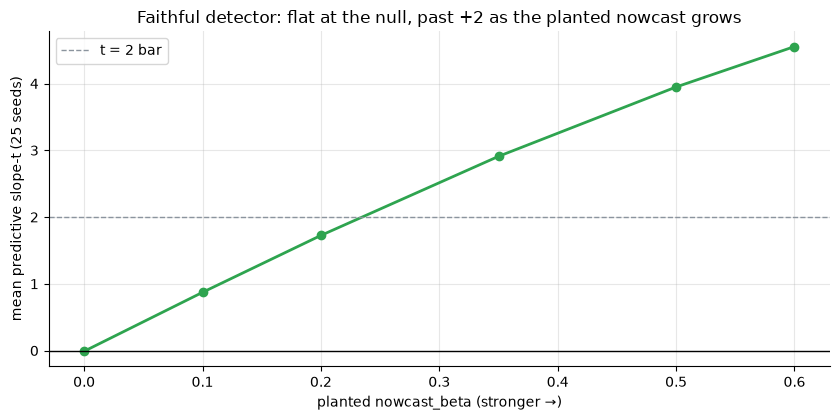

nowcast_beta +0.00 -> mean slope-t -0.01
nowcast_beta +0.10 -> mean slope-t +0.87
nowcast_beta +0.20 -> mean slope-t +1.72
nowcast_beta +0.35 -> mean slope-t +2.91
nowcast_beta +0.50 -> mean slope-t +3.95
nowcast_beta +0.60 -> mean slope-t +4.55


In [5]:
betas = [0.0, 0.10, 0.20, 0.35, 0.50, 0.60]
ts = [st.synthetic_mean_t(data, nowcast_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted nowcast_beta (stronger →)')
ax.set_ylabel('mean predictive slope-t (25 seeds)')
ax.set_title('Faithful detector: flat at the null, past +2 as the planted nowcast grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'nowcast_beta {b:+.2f} -> mean slope-t {t:+.2f}')

The mean slope-*t* is ≈ 0 at the null and rises monotonically past +2 as the planted nowcast grows — so the engine neither misses a real effect nor invents one. The real-tape verdict is therefore **unavailable, not negative**: point this engine at a licensed reservations/foot-traffic panel and it will give an honest read. Until then, `WEAK` × `MIRAGE`. Same synthetic-only footing as [273 Lego-Returns](../../273-lego-returns/), [275 Whisky-Cask](../../275-whisky-cask/) and [276 Sneaker-Resale](../../276-sneaker-resale/).